# Marketing Mix Model — Advertising (TV / Radio / Newspaper → Sales)

## 1. Essential libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
%matplotlib inline

## 2. Load the data

In [2]:
df = pd.read_csv("Advertising.csv", index_col=0)
df.head()

,TV,Radio,Newspaper,Sales
1,230.10,37.80,69.20,22.10
2,44.50,39.30,45.10,10.40
3,17.20,45.90,69.30,9.30
4,151.50,41.30,58.50,18.50
5,180.80,10.80,58.40,12.90


## 3. Initial exploration

In [3]:
print("Shape (rows, columns):", df.shape)
df.info()

Shape (rows, columns): (200, 4)
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 1 to 200
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [4]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.00,200.00,200.00,200.00
mean,147.04,23.26,30.55,14.02
std,85.85,14.85,21.78,5.22
min,0.70,0.00,0.30,1.60
25%,74.38,9.97,12.75,10.38
50%,149.75,22.90,25.75,12.90
75%,218.82,36.52,45.10,17.40
max,296.40,49.60,114.00,27.00


In [5]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

## 4. Exploratory analysis (EDA)

### 4.1 Distribution of each variable

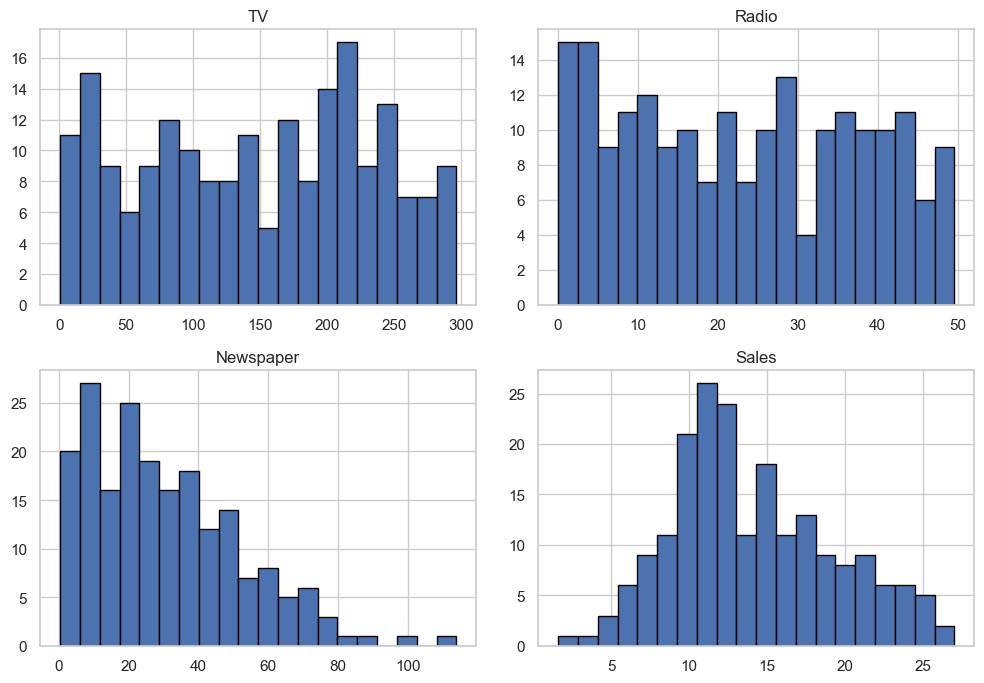

In [6]:
df.hist(bins=20, figsize=(10, 7), edgecolor="black")
plt.tight_layout()
plt.show()

### 4.2 Correlation between channels and sales

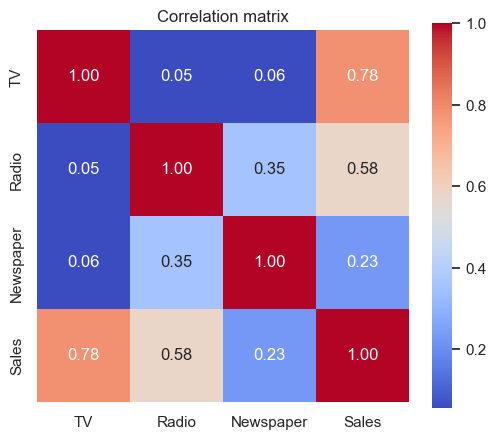

In [7]:
plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation matrix")
plt.show()

> **Note:** TV shows the strongest correlation with Sales (0.78), followed by Radio (0.58); Newspaper is weak (0.23). The channels are barely correlated with each other (≤ 0.35) — an early signal that multicollinearity is unlikely to be an issue.

### 4.3 Relationship between each channel and sales

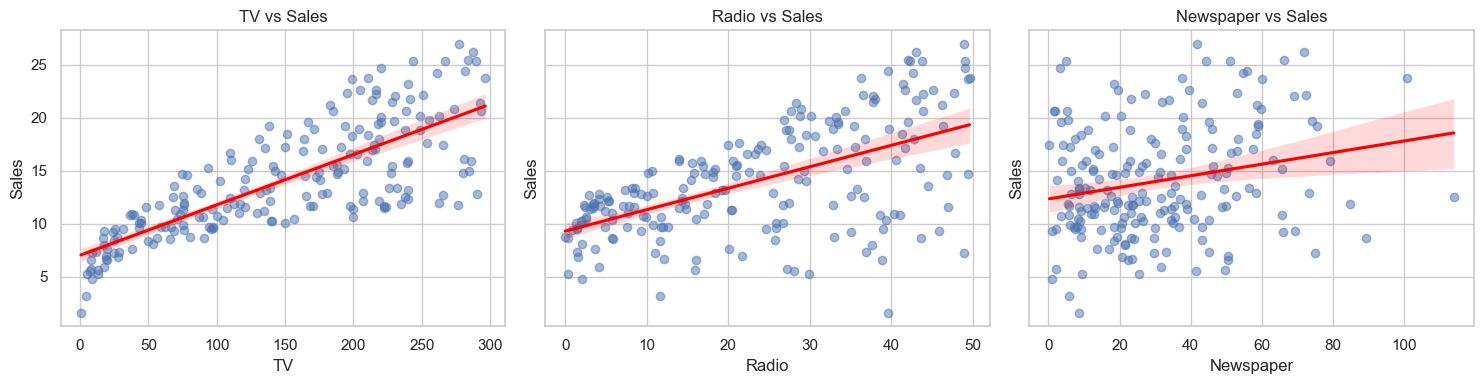

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, channel in zip(axes, ["TV", "Radio", "Newspaper"]):
    sns.regplot(data=df, x=channel, y="Sales", ax=ax,
                scatter_kws={"alpha": 0.5}, line_kws={"color": "red"})
    ax.set_title(f"{channel} vs Sales")
plt.tight_layout()
plt.show()

## 5. Marketing Mix Model — OLS Regression

In [9]:
model = smf.ols(formula="Sales ~ TV + Radio + Newspaper", data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:                Mon, 08 Jun 2026   Prob (F-statistic):           1.58e-96
Time:                        22:23:22   Log-Likelihood:                -386.18
No. Observations:                 200   AIC:                             780.4
Df Residuals:                     196   BIC:                             793.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.9389      0.312      9.422      0.0

> **Note:** The model explains ~90% of sales (R² = 0.897). TV and Radio are highly significant (p < 0.001), but **Newspaper is not** (p = 0.86) — its coefficient is statistically indistinguishable from zero.

## 6. Multicollinearity (VIF)

In [10]:
X = sm.add_constant(df[["TV", "Radio", "Newspaper"]])
vif = pd.DataFrame({
    "variable": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
})
vif

,variable,VIF
0,const,6.85
1,TV,1.00
2,Radio,1.14
3,Newspaper,1.15


> **Note:** All VIFs are ≈ 1 (intercept aside), so there is no multicollinearity. This confirms that Newspaper's insignificance is genuine, not an artifact of correlation with TV or Radio.

## 7. Reduced model — remove Newspaper

In [11]:
reduced_model = smf.ols("Sales ~ TV + Radio", data=df).fit()

comparison = pd.DataFrame(
    {
        "Full (TV+Radio+Newspaper)": [model.rsquared, model.rsquared_adj, model.aic, model.bic],
        "Reduced (TV+Radio)":        [reduced_model.rsquared, reduced_model.rsquared_adj,
                                      reduced_model.aic, reduced_model.bic],
    },
    index=["R²", "Adjusted R²", "AIC", "BIC"],
)
display(comparison)
print(reduced_model.summary())

,Full (TV+Radio+Newspaper),Reduced (TV+Radio)
R²,0.90,0.90
Adjusted R²,0.90,0.90
AIC,780.36,778.39
BIC,793.56,788.29


                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     859.6
Date:                Mon, 08 Jun 2026   Prob (F-statistic):           4.83e-98
Time:                        22:23:23   Log-Likelihood:                -386.20
No. Observations:                 200   AIC:                             778.4
Df Residuals:                     197   BIC:                             788.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.9211      0.294      9.919      0.0

> **Note:** Dropping Newspaper leaves R² essentially unchanged while improving Adjusted R² and lowering AIC/BIC — the parsimonious **TV + Radio** model is preferred.

## 8. Residual validation

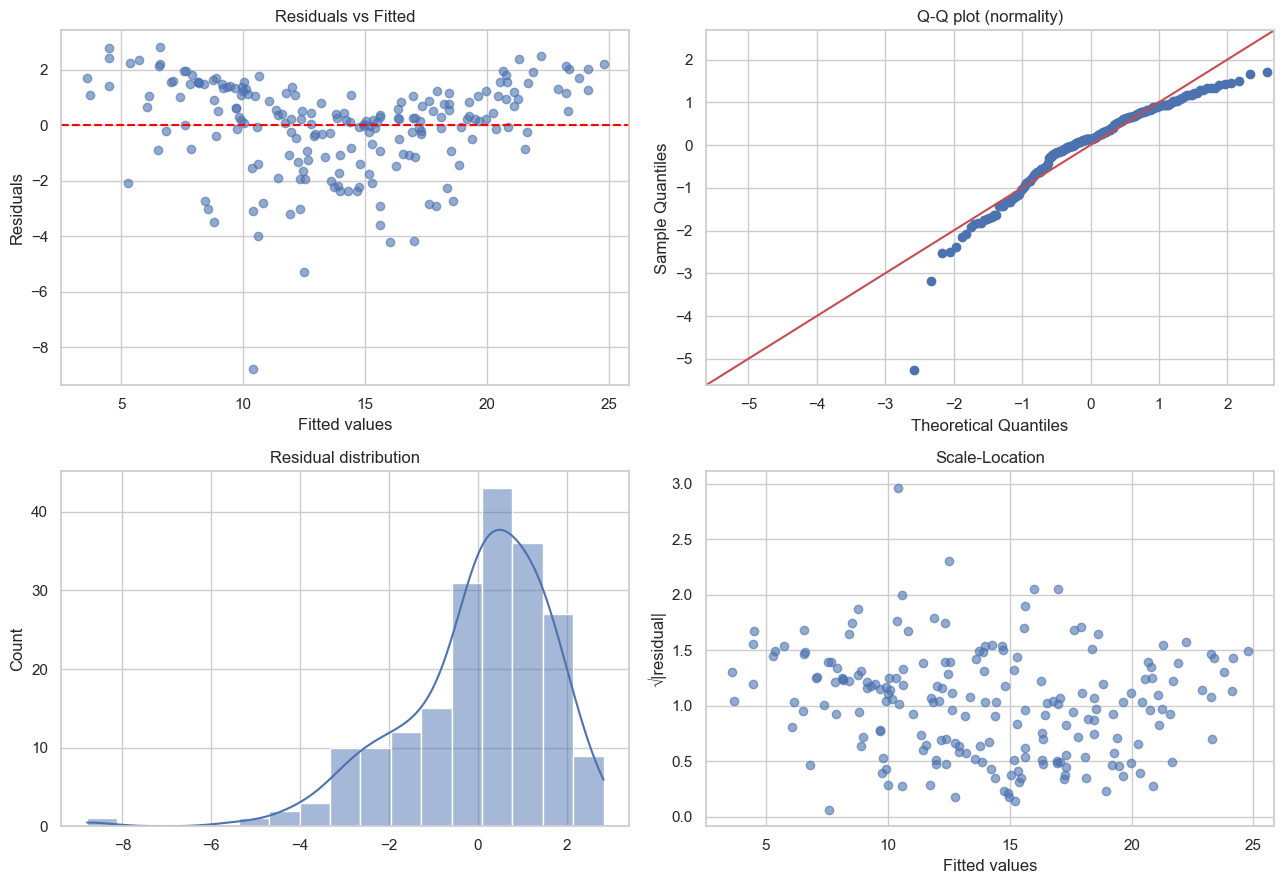

In [12]:
resid = reduced_model.resid
fitted = reduced_model.fittedvalues

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0, 0].scatter(fitted, resid, alpha=0.6)
axes[0, 0].axhline(0, color="red", ls="--")
axes[0, 0].set(xlabel="Fitted values", ylabel="Residuals", title="Residuals vs Fitted")

sm.qqplot(resid, line="45", fit=True, ax=axes[0, 1])
axes[0, 1].set_title("Q-Q plot (normality)")

sns.histplot(resid, kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Residual distribution")

axes[1, 1].scatter(fitted, np.sqrt(np.abs(resid)), alpha=0.6)
axes[1, 1].set(xlabel="Fitted values", ylabel="√|residual|", title="Scale-Location")

plt.tight_layout()
plt.show()

In [13]:
from statsmodels.stats.diagnostic import het_breuschpagan

jb_stat, jb_p, skew, kurt = sm.stats.jarque_bera(resid)
bp = het_breuschpagan(resid, reduced_model.model.exog)
dw = sm.stats.durbin_watson(resid)

print("Residual diagnostics (TV + Radio model)")
print("-" * 50)
print(f"Jarque-Bera (normality)    : stat={jb_stat:6.2f}   p={jb_p:.2e}")
print(f"   Skew = {skew:.2f}   |   Kurtosis = {kurt:.2f}")
print(f"Breusch-Pagan (homosced.)  : p = {bp[1]:.3f}")
print(f"Durbin-Watson (autocorr.)  : {dw:.2f}  (ideal = 2)")

Residual diagnostics (TV + Radio model)
--------------------------------------------------
Jarque-Bera (normality)    : stat=148.68   p=5.19e-33
   Skew = -1.32   |   Kurtosis = 6.29
Breusch-Pagan (homosced.)  : p = 0.090
Durbin-Watson (autocorr.)  : 2.08  (ideal = 2)


> **Note:** Residuals are left-skewed and heavy-tailed (Jarque-Bera p ≈ 0), so normality is violated. The curvature points to a **non-linear** sales response (diminishing returns) that a purely linear model cannot fully capture.

## 9. Channel contribution and efficiency

,Average contribution (k units),Share (%)
Base,2.92,20.83
TV,6.73,47.98
Radio,4.37,31.19


Marginal efficiency (units sold per $k invested):
   TV    : 0.0458
   Radio : 0.1880   ->  Radio yields 4.1x more per dollar at the margin

Average spend:  TV = 147 $k   |   Radio = 23 $k


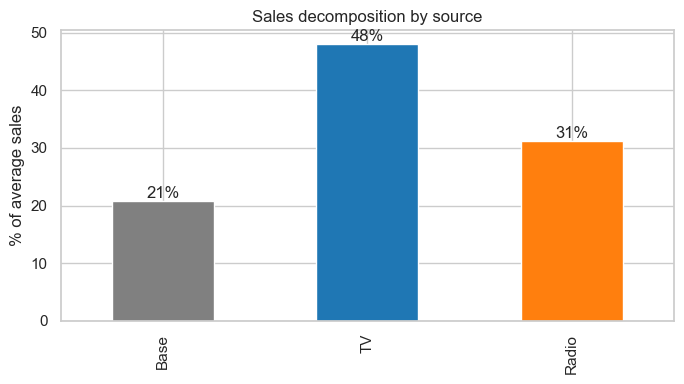

In [14]:
b = reduced_model.params
contrib = pd.DataFrame({
    "Base":  b["Intercept"],
    "TV":    b["TV"]    * df["TV"],
    "Radio": b["Radio"] * df["Radio"],
})
share = contrib.mean() / reduced_model.fittedvalues.mean() * 100

summary_df = pd.DataFrame({
    "Average contribution (k units)": contrib.mean(),
    "Share (%)": share,
})
display(summary_df.round(2))

print("Marginal efficiency (units sold per $k invested):")
print(f"   TV    : {b['TV']:.4f}")
print(f"   Radio : {b['Radio']:.4f}   ->  Radio yields {b['Radio'] / b['TV']:.1f}x more per dollar at the margin")
print(f"\nAverage spend:  TV = {df.TV.mean():.0f} $k   |   Radio = {df.Radio.mean():.0f} $k")

ax = summary_df["Share (%)"].plot(kind="bar", figsize=(7, 4),
                                  color=["gray", "#1f77b4", "#ff7f0e"])
ax.set_ylabel("% of average sales")
ax.set_title("Sales decomposition by source")
for i, v in enumerate(share):
    ax.text(i, v + 0.5, f"{v:.0f}%", ha="center")
plt.tight_layout()
plt.show()

> **Note:** TV drives the largest share of sales by *volume* because it receives ~6× more budget, yet each extra dollar in **Radio returns ~4× more** at the margin — the key lever for reallocating spend.

## 10. Conclusion — case answers

| Question | Answer |
|---|---|
| **Which channels work?** | **TV and Radio** (p < 0.001). **Newspaper has no effect** (p = 0.86) and worsens the AIC. |
| **How much does the model explain?** | **~90%** of sales (R²). Decomposition: base ≈ 21%, TV ≈ 48%, Radio ≈ 31%. |
| **Return per dollar (margin)?** | TV: +0.046 · Radio: **+0.188** units/$k (**~4x more efficient**). |
| **Multicollinearity?** | No (VIF ≈ 1). |
| **Are the residuals well-behaved?** | Not fully: residuals are non-normal (skew ≈ −1.3), hinting at a **non-linear (saturation)** relationship — a natural next step. |
| **Recommendation** | Drop Newspaper; reallocate budget to **Radio** (highest marginal return); keep TV for volume. |